In [68]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\light_house_DBS_decision_making


In [69]:
TRIALS = 100
EPOCHS = 10
BINS = 10
LR = 0.1
NUM_ARMS = 2
SCALING_FACTOR = 100
TIME_STAMP_CHANGE = 50
STATIONARY = False
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE



# Define reward values for each arm
REWARD_VALUES = np.array([10, 10])/SCALING_FACTOR
REWARD_STD = np.array([2, 2])/SCALING_FACTOR

# Define initial probabilities for each arm
INITIAL_PROBS = np.array([0.8, 0.2])

# Define changed reward values (after time_stamp_change)
REWARD_VALUES_CHANGED = np.array([10, 10])/SCALING_FACTOR
REWARD_STD_CHANGED = np.array([2, 2])/SCALING_FACTOR

# Define changed probabilities (after time_stamp_change)
CHANGED_PROBS = np.array([0.2, 0.8])

# Set which parameters to change: 'reward', 'probability', or 'both' : Can change probs or rewards alone or both
CHANGE_TYPE = 'probability'

VAR = 0.25  #0.25 #0.01 #0.01


BEST_ARM_BEFORE = 0
BEST_ARM_AFTER = 1

BEST_ARM = torch.zeros((EPOCHS,TRIALS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  

In [70]:
env = ProbReversalEnv(
    num_arms = NUM_ARMS,
    mean_reward = REWARD_VALUES,
    std = REWARD_STD,
    probabilities = INITIAL_PROBS,
    mean_rew_change = REWARD_VALUES_CHANGED,
    std_change = REWARD_STD_CHANGED,
    probabilities_change = CHANGED_PROBS,
    time_stamp_change = TIME_STAMP_CHANGE,
    change_type = CHANGE_TYPE)


In [71]:

reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, _= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = None, #'rossler',
                                                      d1_amp=0.1,
                                                      d2_amp=0.01, 
                                                      gpi_threshold=0.2,
                                                      max_gpi_iters=50,
                                                      del_lim=None, train_IP = False, 
                                                      del_med = None, printing = True,
                                                      gpi_mean= 1, ep_0 = VAR,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0)

  0%|          | 0/10 [00:00<?, ?it/s]

0: dp: tensor([[0.0501, 0.0501]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([0.0138], grad_fn=<RsubBackward1>), epsilon: 0.25
1: dp: tensor([[0.0554, 0.0501]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([0.0805], grad_fn=<RsubBackward1>), epsilon: 0.25
2: dp: tensor([[0.0603, 0.0501]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([-0.0603], grad_fn=<RsubBackward1>), epsilon: 0.25
3: dp: tensor([[0.0609, 0.0501]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([0.0467], grad_fn=<RsubBackward1>), epsilon: 0.25
4: dp: tensor([[0.0629, 0.0501]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([-0.0629], grad_fn=<RsubBackward1>), epsilon: 0.25
5: dp: tensor([[0.0626, 0.0501]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([0.0617], grad_fn=<RsubBackward1>), epsilon: 0.25
6: dp: tensor([[0.0639, 0.0501]], grad_fn=<MulBackward0>), arm_chosen:0, TD error: tensor([0.0782], grad_fn=<RsubBackward1>), epsilon: 0.25
7: dp: tensor([[0.

In [72]:
mean_picks = {key: torch.mean(avg_counts[key], dim = 0) for key in list(avg_counts.keys())}
IP_avg = {key: torch.mean(ip_monitor[key], dim =0).detach().numpy() for key in list(ip_monitor.keys())}
DP_avg = {key: torch.mean(dp_monitor[key], dim =0).detach().numpy() for key in list(dp_monitor.keys())}
IP_var = np.std(np.stack(list(IP_avg.values()), axis=0),axis = 0)[:,0]
arm_chosen_monitor = arm_chosen_monitor.to(torch.int)

# Computing Accuracy
accuracy_percentages = torch.zeros((EPOCHS, BINS))

for i in range(BINS):
    start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
    correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
    accuracy_percentages[:, i] = (correct_choices / BIN_SIZE) * 100

accuracy_per_bin = torch.mean(accuracy_percentages,axis = 0)

[ 1  2  3  4  5  6  7  8  9 10]


Text(0.5, 0, 'bins')

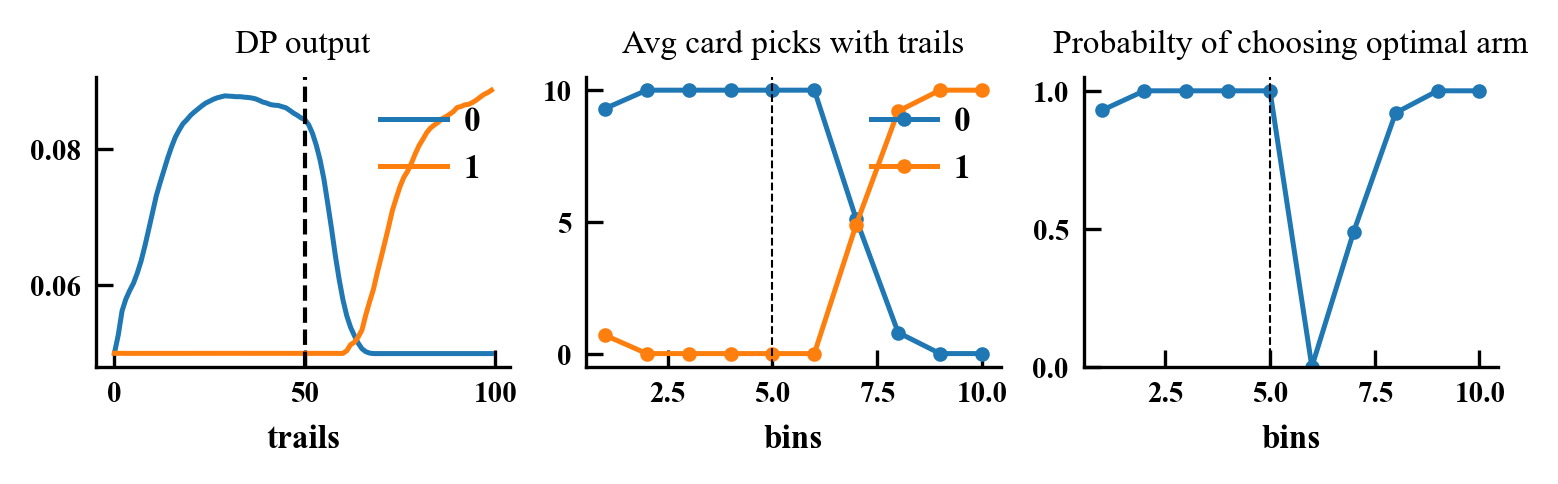

In [73]:
BIN = np.arange(BINS)+1
print(BIN)

plt.figure(figsize=(5,1.5))
plt.subplot(131)
for i in DP_avg.keys():
    plt.plot(np.arange(TRIALS), DP_avg[i], label = i)
plt.axvline(x=TIME_STAMP_CHANGE, color='black', linestyle='--', linewidth=1)
plt.xlabel('trails')
plt.title('DP output')
plt.legend(loc = 'upper right')

plt.subplot(132)

for i in mean_picks.keys():
    plt.plot(BIN,mean_picks[i], label = i, marker = '.', markersize = 5)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.title('Avg card picks with trails')
plt.xlabel('bins')
plt.legend(loc = 'upper right')

plt.subplot(133)
plt.plot(BIN, accuracy_per_bin/100, marker = '.', markersize = 5)
plt.axvline(x=BIN_CHANGE, color='black', linestyle='--', linewidth=0.5)
plt.title('Probabilty of choosing optimal arm')
plt.ylim(0,1.05)
plt.xlabel('bins')



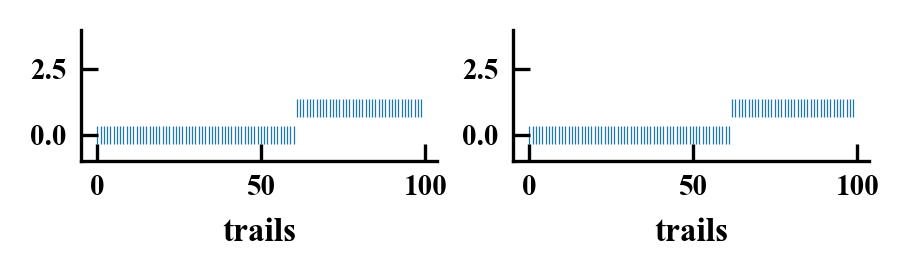

In [74]:
random_epochs = np.random.choice(np.arange(EPOCHS), size = 2)
i = 1
plt.figure(figsize=(3,1))
for e in random_epochs:
    plt.subplot(1,2,i)
    colors = np.where(np.isin(arm_chosen_monitor[e],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRIALS), arm_chosen_monitor[e], marker = '|', s = 20, lw = 0.3)
    plt.ylim(-1,4)
    plt.xlabel('trails')
    i+=1

# plt.suptitle('Card picks in each epoch')
plt.tight_layout()

In [75]:
accuracy_per_bin

tensor([ 93., 100., 100., 100., 100.,   0.,  49.,  92., 100., 100.])